# CAV – wersja hierarchiczna z HCEP



In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import clip
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from data_loading import load_sun_data
import torchvision.models as models
from torchvision import transforms as trn
import torch.nn as nn
from tqdm import tqdm
from dataloaders import create_sun_dataloader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Używane urządzenie: {DEVICE}')

Używane urządzenie: cuda


## 21. Definicja funkcji CAV

### 1.1 Standardowy MeanDiff (bazowy, do porównania)

In [3]:
def calculate_meandiff_cav(features_matrix, concept_indices, background_indices=None):
    """Klasyczny MeanDiff CAV: mean(concept) - mean(background), znormalizowany."""
    mean_concept = np.mean(features_matrix[concept_indices], axis=0)
    if background_indices is None:
        mean_background = np.mean(features_matrix, axis=0)
    else:
        mean_background = np.mean(features_matrix[background_indices], axis=0)
    cav = mean_concept - mean_background
    norm = np.linalg.norm(cav)
    if norm > 1e-8:
        cav = cav / norm
    return cav

### 1.2 HCEP – Hierarchical Concept Embedding Projection

In [1]:
def calculate_hcep_cav(features_matrix, concept_indices, background_indices, parent_cav=None):
    """
    Algorytm:
      1. Oblicz surowy MeanDiff: CAV_raw = mean(concept) - mean(background)
      2. Jeśli podany parent_cav (wektor rodzica, jednostkowy):
         - Oblicz projekcję: proj = (CAV_raw . parent_cav) * parent_cav
         - Usuń komponentę rodzica: CAV_perp = CAV_raw - proj
      3. Znormalizuj: CAV_hcep = CAV_perp / ||CAV_perp||

    Wynikowy wektor jest ortogonalny do parent_cav.

    Parametry
    ----------
    features_matrix : np.ndarray, shape (N, D)
    concept_indices : list[int]  - indeksy próbek z pojęciem dziecka
    background_indices : list[int]  - indeksy tła
    parent_cav : np.ndarray shape (D,) | None

    Zwraca
    ------
    np.ndarray shape (D,) - znormalizowany HCEP CAV
    """
    mean_concept = np.mean(features_matrix[concept_indices], axis=0)
    mean_background = np.mean(features_matrix[background_indices], axis=0)
    cav_raw = mean_concept - mean_background

    if parent_cav is not None:
        projection_scalar = np.dot(cav_raw, parent_cav)
        projection_vector = projection_scalar * parent_cav
        cav_raw = cav_raw - projection_vector

    norm = np.linalg.norm(cav_raw)
    if norm > 1e-8:
        cav_raw = cav_raw / norm
    else:
        raise ValueError(
            'Norma CAV po projekcji jest bliska zeru - pojęcie i rodzic mogą być '
            'prawie identyczne w przestrzeni cech.'
        )
    return cav_raw


def get_cosine_similarity(vec1, vec2):
    return cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]


def projection_ratio(child_cav_raw, parent_cav):
    """Jaka część energii dziecka leżała wzdłuż rodzica (przed projekcją HCEP)."""
    return float(np.dot(child_cav_raw, parent_cav) ** 2)

## 2. Wczytanie danych i ekstrakcja cech

In [5]:
df_sun, attributes_list, attr_cols = load_sun_data(
    base_path='data/SUN/SUNAttributeDB', threshold=0.5
)
print(f'Wczytano obrazy: {len(df_sun)}')
print(f'Liczba atrybutów: {len(attr_cols)}')
df_sun.head(3)

Wczytano obrazy: 14340
Liczba atrybutów: 102


,image_id,file_path,class_id,sailing/ boating,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Model ResNet18 
model_file = 'models/resnet18_places365.pth'
conv_model_places = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model_places.load_state_dict(state_dict)
conv_model_places.fc = nn.Identity()
conv_model_places = conv_model_places.to(DEVICE).eval()

# CLIP
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('Zaladowano: ResNet18-Places365, CLIP ViT-B/32')

Zaladowano: ResNet18-Places365, ResNet18-ImageNet, CLIP ViT-B/32


In [8]:
dataloader_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)
dataloader_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4
)

In [9]:
features_places = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_resnet, desc='ResNet18-Places365 features'):
        feats = conv_model_places(batch_imgs.to(DEVICE))
        features_places.append(feats.cpu().numpy())
X_places = np.concatenate(features_places, axis=0)
print(f'Places365 features: {X_places.shape}')

ResNet18-Places365 features: 100%|██████████| 449/449 [00:41<00:00, 10.83it/s]

Places365 features: (14340, 512)


In [10]:
features_clip = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_clip, desc='CLIP features'):
        feats = clip_model.encode_image(batch_imgs.to(DEVICE)).float()
        feats = feats / feats.norm(dim=1, keepdim=True)
        features_clip.append(feats.cpu().numpy())
X_clip = np.concatenate(features_clip, axis=0)
print(f'CLIP features: {X_clip.shape}')

CLIP features: 100%|██████████| 225/225 [00:33<00:00,  6.78it/s]

CLIP features: (14340, 512)


## 3. Definicja hierarchii pojęć

Używamy tych samych par co w notebooku MeanDiff.  
Klucz: `(child, parent)` - child jest pojęciem podrzędnym wewnątrz parent.

In [11]:
empirical_pairs = [
    ('research',          'enclosed area'),
    ('camping',           'open area'),
    ('medical activity',  'enclosed area'),
    ('gaming',            'enclosed area'),
    ('sand',              'natural light'),
    ('carpet',            'enclosed area'),
]

semantic_pairs = [
    ('ocean',               'open area'),
    ('conducting business', 'working'),
    ('pavement',            'asphalt'),
    ('climbing',            'rock/stone'),
    ('rusty',               'aged/ worn'),
    ('ice',                 'cold'),
]

all_pairs = empirical_pairs + semantic_pairs
child_to_parent = {child: parent for child, parent in all_pairs}

all_concepts = set()
for child, parent in all_pairs:
    all_concepts.add(child)
    all_concepts.add(parent)

print(f'Laczna liczba pojec: {len(all_concepts)}')
print('Pary (dziecko -> rodzic):')
for c, p in all_pairs:
    print(f'  {c} -> {p}')

Laczna liczba pojec: 20
Pary (dziecko -> rodzic):
  research -> enclosed area
  camping -> open area
  medical activity -> enclosed area
  gaming -> enclosed area
  sand -> natural light
  carpet -> enclosed area
  ocean -> open area
  conducting business -> working
  pavement -> asphalt
  climbing -> rock/stone
  rusty -> aged/ worn
  ice -> cold


## 4. Obliczenie HCEP CAV

### Procedura dla każdej pary (dziecko, rodzic):
1. `CAV_parent` metodą MeanDiff
2. `CAV_child_raw` metodą MeanDiff
3. Projekcja HCEP: `CAV_child_hcep = CAV_child_raw - proj(CAV_child_raw -> CAV_parent)`
4. Normalizacja


In [ ]:
def compute_hcep_cavs_for_pairs(pairs, df, features, label):
    results = []
    cavs = {}

    for child, parent in pairs:
        idx_child_pos  = df.index[df[child]  == 1.0].tolist()
        idx_child_neg  = df.index[df[child]  == 0.0].tolist()
        idx_parent_pos = df.index[df[parent] == 1.0].tolist()
        idx_parent_neg = df.index[df[parent] == 0.0].tolist()

        cav_parent = calculate_meandiff_cav(features, idx_parent_pos, idx_parent_neg)
        cavs[parent] = cav_parent

        cav_child_raw = calculate_meandiff_cav(features, idx_child_pos, idx_child_neg)
        cos_before = get_cosine_similarity(cav_child_raw, cav_parent)
        proj_r = float(np.dot(cav_child_raw, cav_parent) ** 2)

        try:
            cav_child_hcep = calculate_hcep_cav(
                features, idx_child_pos, idx_child_neg, parent_cav=cav_parent
            )
        except ValueError as e:
            print(f'  [UWAGA] {child}: {e}')
            cav_child_hcep = cav_child_raw

        cavs[child + '_hcep'] = cav_child_hcep
        cavs[child + '_raw']  = cav_child_raw

        cos_after = get_cosine_similarity(cav_child_hcep, cav_parent)

        results.append({
            'Model': label,
            'Dziecko': child,
            'Rodzic': parent,
            'n_child': len(idx_child_pos),
            'n_parent': len(idx_parent_pos),
            'cos(child_raw, parent)': round(cos_before, 4),
            'proj_ratio (R2)': round(proj_r, 4),
            'cos(child_hcep, parent)': round(cos_after, 6),
        })

    return pd.DataFrame(results), cavs



Funkcja compute_hcep_cavs_for_pairs gotowa.


In [ ]:
print('=== ResNet18 - Places365 ===')
df_hcep_places, cavs_places = compute_hcep_cavs_for_pairs(
    all_pairs, df_sun, X_places, 'ResNet18-Places365'
)

print('\n=== CLIP ViT-B/32 ===')
df_hcep_clip, cavs_clip = compute_hcep_cavs_for_pairs(
    all_pairs, df_sun, X_clip, 'CLIP'
)

df_hcep_all = pd.concat([df_hcep_places,  df_hcep_clip], ignore_index=True)

=== ResNet18 - Places365 ===

=== CLIP ViT-B/32 ===


### 4.1 Wynik projekcji: ile energii dziecka leżało wzdłuż rodzica?

Kolumna `proj_ratio (R2)`: udział wariancji wektora dziecka wzdłuż osi rodzica.   


In [16]:
print('\n-- Wyniki projekcji HCEP (wszystkie modele) --')
print(df_hcep_all.to_string(index=False))


-- Wyniki projekcji HCEP (wszystkie modele) --
             Model             Dziecko        Rodzic  n_child  n_parent  cos(child_raw, parent)  proj_ratio (R2)  cos(child_hcep, parent)
ResNet18-Places365            research enclosed area      207      4947                  0.7293           0.5318                     -0.0
ResNet18-Places365             camping     open area      871      5541                  0.7919           0.6270                      0.0
ResNet18-Places365    medical activity enclosed area      118      4947                  0.6150           0.3782                     -0.0
ResNet18-Places365              gaming enclosed area      108      4947                  0.6190           0.3831                      0.0
ResNet18-Places365                sand natural light      351      6709                  0.6086           0.3704                      0.0
ResNet18-Places365              carpet enclosed area      324      4947                  0.8100           0.6561            

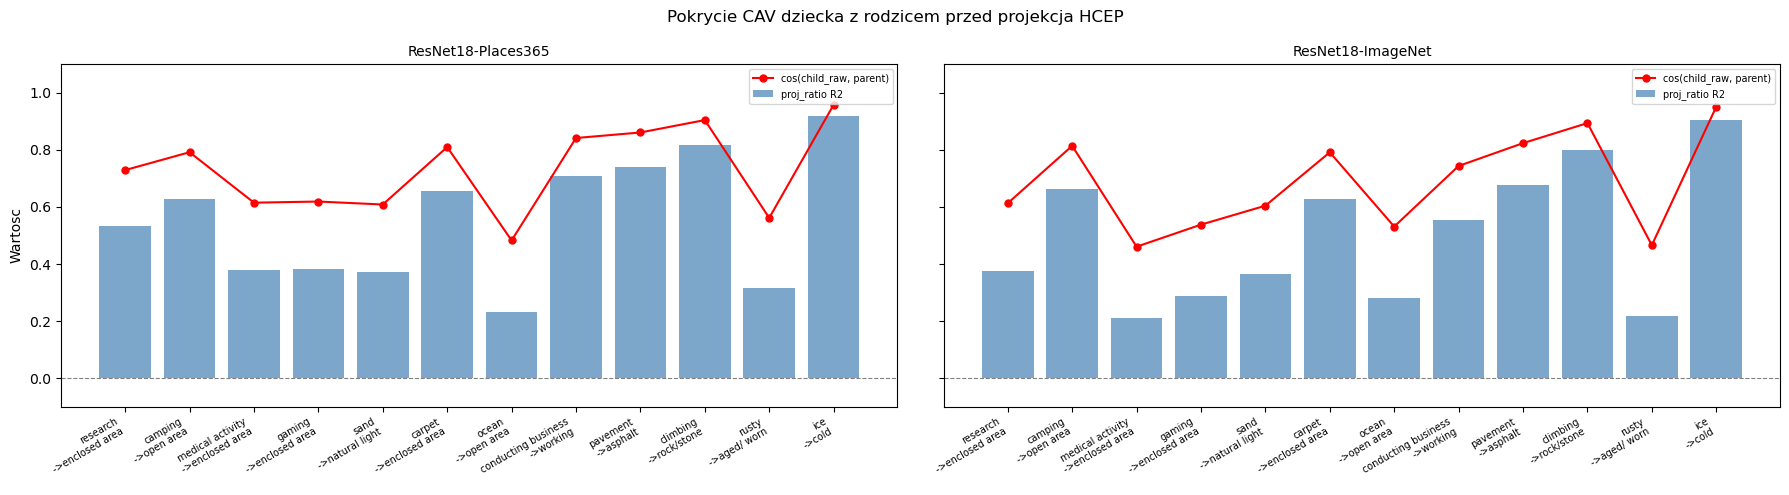

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
model_labels = ['ResNet18-Places365', 'ResNet18-ImageNet', 'CLIP']
dfs = [df_hcep_places,  df_hcep_clip]

for ax, label, df_m in zip(axes, model_labels, dfs):
    pairs_labels = [f"{r['Dziecko']}\n->{r['Rodzic']}" for _, r in df_m.iterrows()]
    proj_vals = df_m['proj_ratio (R2)'].values
    cos_before = df_m['cos(child_raw, parent)'].values

    x = np.arange(len(pairs_labels))
    ax.bar(x, proj_vals, color='steelblue', alpha=0.7, label='proj_ratio R2')
    ax.plot(x, cos_before, 'ro-', label='cos(child_raw, parent)', markersize=5)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(pairs_labels, fontsize=7, rotation=30, ha='right')
    ax.set_title(label, fontsize=10)
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Wartosc')
fig.suptitle('Pokrycie CAV dziecka z rodzicem przed projekcja HCEP', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Ewaluacja HCEP CAV - AUC na zbiorze testowym

Sprawdzamy jakość HCEP CAV jako klasyfikatora pojęć, porównując go z MeanDiff.

In [ ]:
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

print(f'Trening: {len(train_idx)} | Test: {len(test_idx)}')

splits = {
    'ResNet18-Places365': (X_places[train_idx],   X_places[test_idx]),
    'CLIP':               (X_clip[train_idx],     X_clip[test_idx]),
}

df_train_meta = df_sun.iloc[train_idx].reset_index(drop=True)
df_test_meta  = df_sun.iloc[test_idx].reset_index(drop=True)

Trening: 11472 | Test: 2868


In [20]:
def evaluate_cavs(pairs, df_train, df_test, X_train, X_test, model_label):
    records = []

    for child, parent in pairs:
        idx_child_pos_tr  = df_train.index[df_train[child]  == 1.0].tolist()
        idx_child_neg_tr  = df_train.index[df_train[child]  == 0.0].tolist()
        idx_parent_pos_tr = df_train.index[df_train[parent] == 1.0].tolist()
        idx_parent_neg_tr = df_train.index[df_train[parent] == 0.0].tolist()

        cav_parent = calculate_meandiff_cav(X_train, idx_parent_pos_tr, idx_parent_neg_tr)
        cav_md     = calculate_meandiff_cav(X_train, idx_child_pos_tr, idx_child_neg_tr)

        try:
            cav_hcep = calculate_hcep_cav(
                X_train, idx_child_pos_tr, idx_child_neg_tr, parent_cav=cav_parent
            )
        except ValueError:
            cav_hcep = cav_md

        y_test = df_test[child].values
        scores_md   = cosine_similarity(X_test, cav_md.reshape(1,   -1)).flatten()
        scores_hcep = cosine_similarity(X_test, cav_hcep.reshape(1, -1)).flatten()

        auc_md   = roc_auc_score(y_test, scores_md)
        auc_hcep = roc_auc_score(y_test, scores_hcep)

        hard_mask   = (df_test[parent] == 1.0).values
        y_test_hard = y_test[hard_mask]
        X_test_hard = X_test[hard_mask]

        auc_md_hard = auc_hcep_hard = None

        if len(np.unique(y_test_hard)) > 1:
            s_md_h   = cosine_similarity(X_test_hard, cav_md.reshape(1,   -1)).flatten()
            s_hcep_h = cosine_similarity(X_test_hard, cav_hcep.reshape(1, -1)).flatten()
            auc_md_hard   = roc_auc_score(y_test_hard, s_md_h)
            auc_hcep_hard = roc_auc_score(y_test_hard, s_hcep_h)

        records.append({
            'Model':         model_label,
            'Dziecko':       child,
            'Rodzic':        parent,
            'AUC_MeanDiff':  round(auc_md,   3),
            'AUC_HCEP':      round(auc_hcep, 3),
            'Delta':         round(auc_hcep - auc_md, 3),
            'AUC_MD_Hard':   round(auc_md_hard,   3) if auc_md_hard   else None,
            'AUC_HCEP_Hard': round(auc_hcep_hard, 3) if auc_hcep_hard else None,
            'Delta_Hard':    round((auc_hcep_hard or 0) - (auc_md_hard or 0), 3)
                             if (auc_hcep_hard and auc_md_hard) else None,
        })

    return pd.DataFrame(records)

print('Funkcja evaluate_cavs gotowa.')

Funkcja evaluate_cavs gotowa.


In [21]:
eval_dfs = {}
for model_label, (X_tr, X_te) in splits.items():
    print(f'\n{"="*60}')
    print(f'  Ewaluacja: {model_label}')
    print(f'{"="*60}')
    df_eval = evaluate_cavs(
        all_pairs, df_train_meta, df_test_meta, X_tr, X_te, model_label
    )
    eval_dfs[model_label] = df_eval
    print(df_eval[['Dziecko', 'Rodzic', 'AUC_MeanDiff', 'AUC_HCEP',
                   'Delta', 'AUC_MD_Hard', 'AUC_HCEP_Hard', 'Delta_Hard'
                  ]].to_string(index=False))


  Ewaluacja: ResNet18-Places365
            Dziecko        Rodzic  AUC_MeanDiff  AUC_HCEP  Delta  AUC_MD_Hard  AUC_HCEP_Hard  Delta_Hard
           research enclosed area         0.958     0.922 -0.036        0.888          0.896       0.008
            camping     open area         0.959     0.916 -0.044        0.911          0.903      -0.008
   medical activity enclosed area         0.980     0.960 -0.021        0.946          0.948       0.002
             gaming enclosed area         0.965     0.948 -0.017        0.947          0.945      -0.002
               sand natural light         0.955     0.953 -0.002        0.916          0.934       0.017
             carpet enclosed area         0.914     0.789 -0.125        0.770          0.769      -0.001
              ocean     open area         0.982     0.981 -0.001        0.967          0.971       0.004
conducting business       working         0.893     0.802 -0.091        0.646          0.693       0.047
           pavement   



### 5.1 Podsumowanie zbiorcze

In [22]:
df_combined = pd.concat(eval_dfs.values(), ignore_index=True)

df_agg = df_combined.groupby(['Dziecko', 'Rodzic']).agg(
    AUC_MD_mean   = ('AUC_MeanDiff', 'mean'),
    AUC_HCEP_mean = ('AUC_HCEP',     'mean'),
    Delta_mean    = ('Delta',         'mean'),
).round(3).reset_index()

df_agg['Ocena HCEP'] = df_agg['Delta_mean'].apply(
    lambda d: 'HCEP lepszy' if d > 0.01
              else ('Porownywalny' if abs(d) <= 0.01 else 'HCEP gorszy')
)

print('\n-- Srednie AUC po modelach --')
print(df_agg.to_string(index=False))


-- Srednie AUC po modelach --
            Dziecko        Rodzic  AUC_MD_mean  AUC_HCEP_mean  Delta_mean   Ocena HCEP
            camping     open area        0.952          0.893      -0.060  HCEP gorszy
             carpet enclosed area        0.908          0.787      -0.121  HCEP gorszy
           climbing    rock/stone        0.912          0.770      -0.141  HCEP gorszy
conducting business       working        0.906          0.815      -0.090  HCEP gorszy
             gaming enclosed area        0.970          0.956      -0.014  HCEP gorszy
                ice          cold        0.983          0.764      -0.219  HCEP gorszy
   medical activity enclosed area        0.985          0.970      -0.016  HCEP gorszy
              ocean     open area        0.980          0.972      -0.008 Porownywalny
           pavement       asphalt        0.891          0.732      -0.158  HCEP gorszy
           research enclosed area        0.962          0.925      -0.037  HCEP gorszy
            

### 5.2 Wizualizacja: MeanDiff vs HCEP

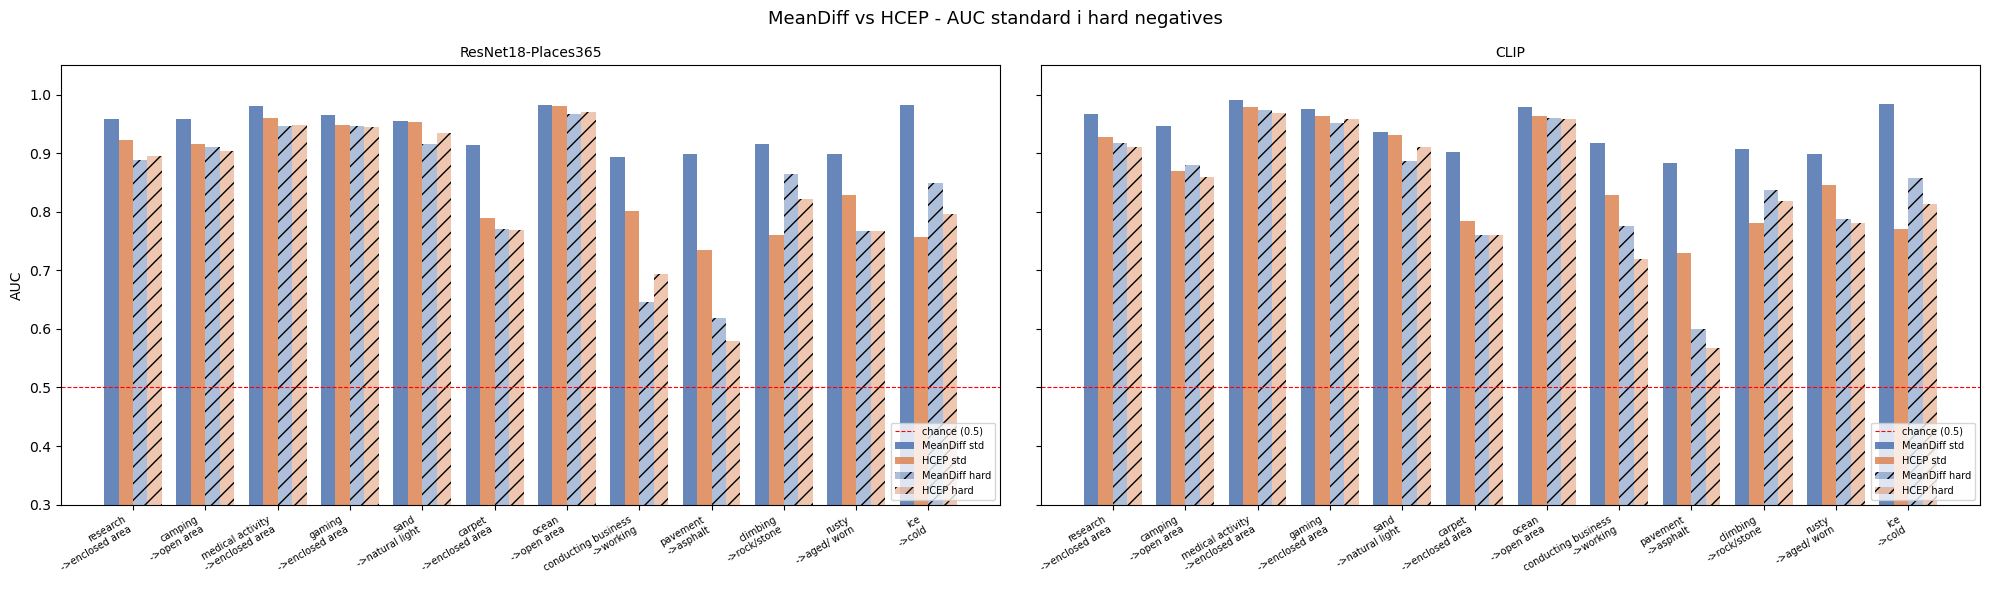

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, (model_label, df_m) in zip(axes, eval_dfs.items()):
    pair_labels = [f"{r['Dziecko']}\n->{r['Rodzic']}" for _, r in df_m.iterrows()]
    x = np.arange(len(pair_labels))
    w = 0.2

    ax.bar(x - 1.5*w, df_m['AUC_MeanDiff'],            w, label='MeanDiff std',  color='#4C72B0', alpha=0.85)
    ax.bar(x - 0.5*w, df_m['AUC_HCEP'],               w, label='HCEP std',       color='#DD8452', alpha=0.85)
    ax.bar(x + 0.5*w, df_m['AUC_MD_Hard'].fillna(0),   w, label='MeanDiff hard', color='#4C72B0', alpha=0.45, hatch='//')
    ax.bar(x + 1.5*w, df_m['AUC_HCEP_Hard'].fillna(0), w, label='HCEP hard',     color='#DD8452', alpha=0.45, hatch='//')

    ax.axhline(0.5, color='red', lw=0.8, ls='--', label='chance (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=7, rotation=30, ha='right')
    ax.set_title(model_label, fontsize=10)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_ylabel('AUC')
fig.suptitle('MeanDiff vs HCEP - AUC standard i hard negatives', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Podział na pary semantyczne vs empiryczne


-- Srednie AUC według typu hierarchii --
             AUC_MeanDiff  AUC_HCEP  Delta
Typ                                       
Empiryczna          0.954     0.912 -0.042
Semantyczna         0.928     0.815 -0.113


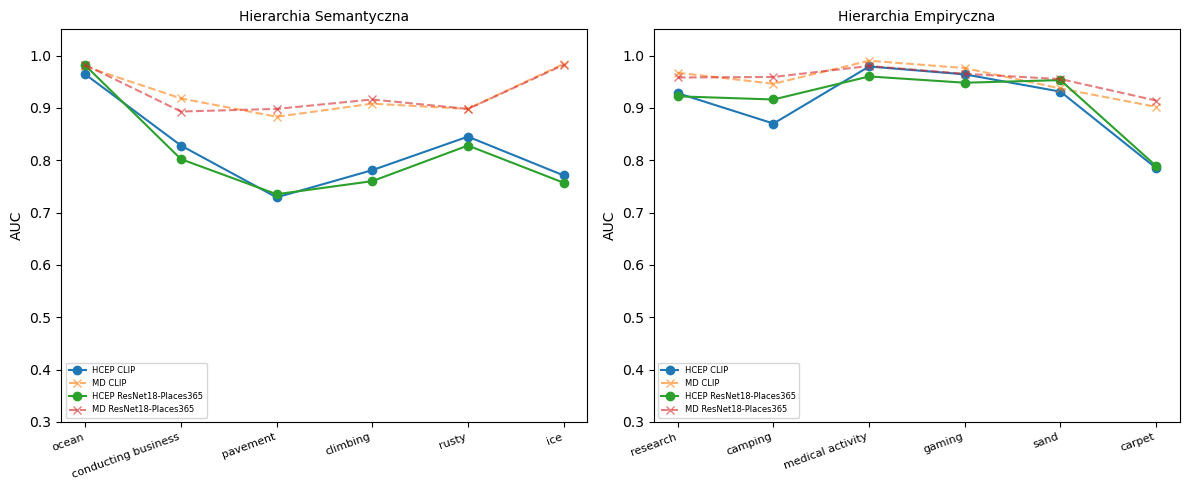

In [ ]:
semantic_children  = {c for c, _ in semantic_pairs}
empirical_children = {c for c, _ in empirical_pairs}

df_combined['Typ'] = df_combined['Dziecko'].apply(
    lambda c: 'Semantyczna' if c in semantic_children else 'Empiryczna'
)

summary_by_type = df_combined.groupby('Typ')[['AUC_MeanDiff', 'AUC_HCEP', 'Delta']].mean().round(3)
print('\n-- Srednie AUC według typu hierarchii --')
print(summary_by_type)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, typ in zip(axes, ['Semantyczna', 'Empiryczna']):
    sub = df_combined[df_combined['Typ'] == typ]
    children = sub['Dziecko'].unique()
    x = np.arange(len(children))
    for model_label, grp in sub.groupby('Model'):
        ax.plot(x, grp['AUC_HCEP'].values,     marker='o', label=f'HCEP {model_label}')
        ax.plot(x, grp['AUC_MeanDiff'].values,  marker='x', ls='--', label=f'MD {model_label}', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(children, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'Hierarchia {typ}', fontsize=10)
    ax.set_ylim(0.3, 1.05)
    ax.set_ylabel('AUC')
    ax.legend(fontsize=6)

plt.tight_layout()
plt.show()